In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import warnings 
warnings.filterwarnings('ignore')

print("All libraries imported")

All libraries imported


In [6]:
train = pd.read_csv("../data/twitter_training.csv",header=None,names=['id','entity','sentiment','text'])

val = pd.read_csv("../data/twitter_validation.csv",header=None,names=['id','entity','sentiment','text'])

df = pd.concat([train,val],ignore_index=True)  

print(f"Training rows : {len(train)}")
print(f"Validation rows : {len(val)}")
print(f"Total rows : {len(df)}")
df.head()

Training rows : 74682
Validation rows : 1000
Total rows : 75682


,id,entity,sentiment,text
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


In [8]:
# Basic Info

print("Shape : ",df.shape)
print("\nColumns types : ")
print(df.dtypes)
print("\nMissing values : ")
print(df.isnull().sum())

Shape :  (75682, 4)

Columns types : 
id           int64
entity         str
sentiment      str
text           str
dtype: object

Missing values : 
id             0
entity         0
sentiment      0
text         686
dtype: int64


In [9]:
# Drop missing and 'Irrelevant Sentiment'

df = df.dropna(subset=['text'])

df = df[df['sentiment']!= 'Irrelevant']

df = df.reset_index(drop=True)

print(f"Rows after cleaning : {len(df)}")
print(f"Sentiments remaining : {df['sentiment'].unique()}")

Rows after cleaning : 61949
Sentiments remaining : <ArrowStringArray>
['Positive', 'Neutral', 'Negative']
Length: 3, dtype: str


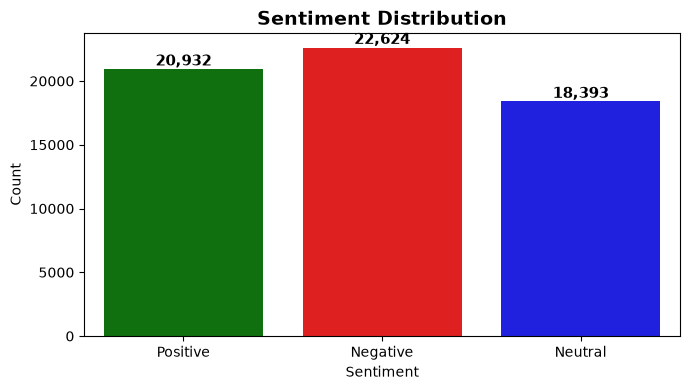


Class Percentages : 
sentiment
Negative    36.5%
Positive    33.8%
Neutral     29.7%
Name: proportion, dtype: str


In [20]:
# Sentiment Distribution

plt.figure(figsize=(7,4))
# colors = ['#2ecc71', '#e74c3c', '#3498db']
colors = ['green','red','blue']

ax = sns.countplot(x='sentiment',data=df,order=['Positive','Negative','Neutral'],palette=colors)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
               (p.get_x() + p.get_width()/2,p.get_height()),
               ha='center',va='bottom',fontsize=11, fontweight='bold')

plt.title("Sentiment Distribution",fontsize=14,fontweight='bold')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

print("\nClass Percentages : ")
print(df['sentiment'].value_counts(normalize=True).mul(100).round(1).astype(str)+'%')

           text_length  word_count
sentiment                         
Negative         111.4        20.1
Neutral          119.3        20.3
Positive          96.2        17.2


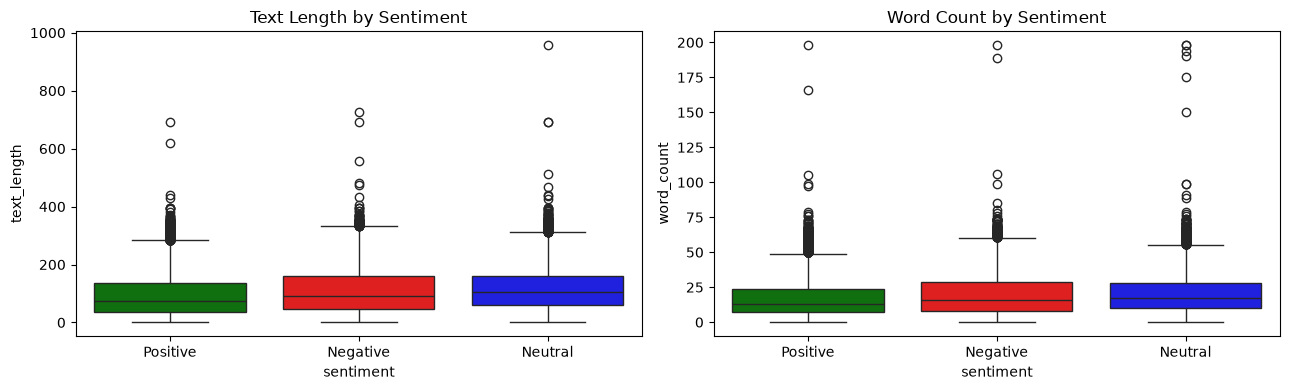

In [22]:
df['text_length'] = df['text'].astype(str).apply(len)
df['word_count']  = df['text'].astype(str).apply(lambda x: len(x.split()))

print(df.groupby('sentiment')[['text_length','word_count']].mean().round(1))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, col, title in zip(axes,
    ['text_length', 'word_count'],
    ['Text Length by Sentiment', 'Word Count by Sentiment']):
    sns.boxplot(x='sentiment', y=col, data=df,
                order=['Positive','Negative','Neutral'],
                palette = ['green','red','blue'],ax=ax)

    ax.set_title(title)
plt.tight_layout()
plt.show()

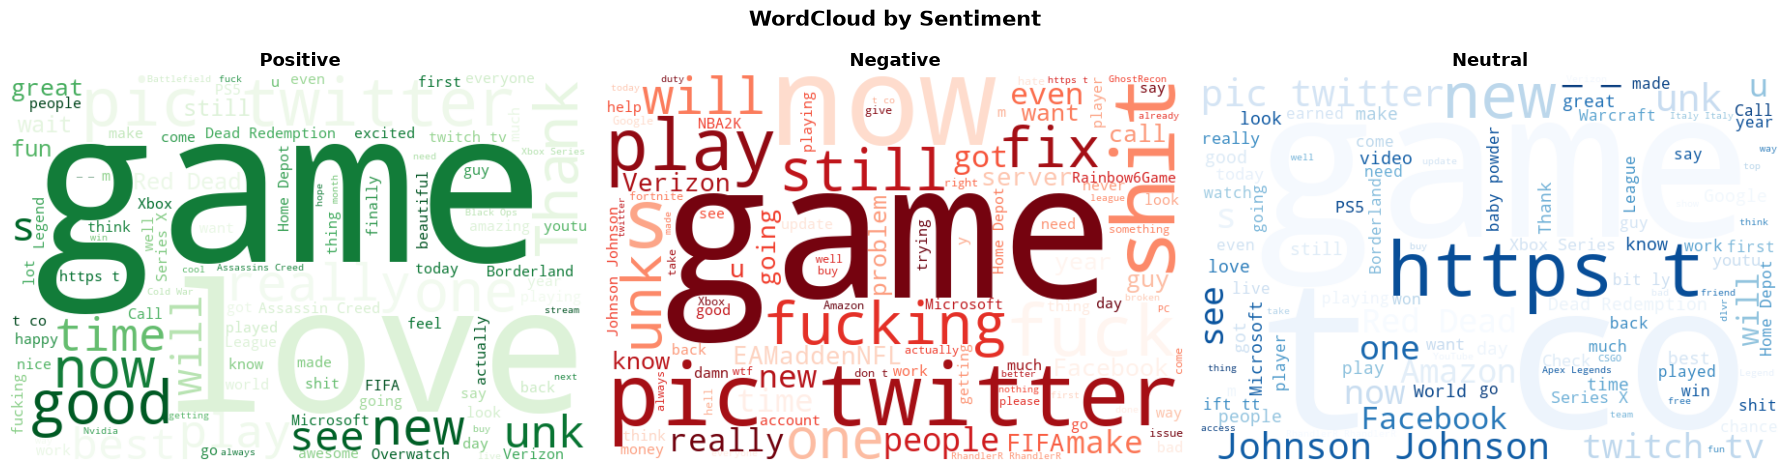

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, sentiment, cmap in zip(axes,
    ['Positive', 'Negative', 'Neutral'],
    ['Greens',   'Reds',     'Blues']):

    text = ' '.join(df[df['sentiment'] == sentiment]['text'].astype(str))
    wc   = WordCloud(width=600, height=400,
                     background_color='white',
                     colormap=cmap, max_words=100).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f'{sentiment}', fontsize=13, fontweight='bold')
    ax.axis('off')

plt.suptitle('WordCloud by Sentiment', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

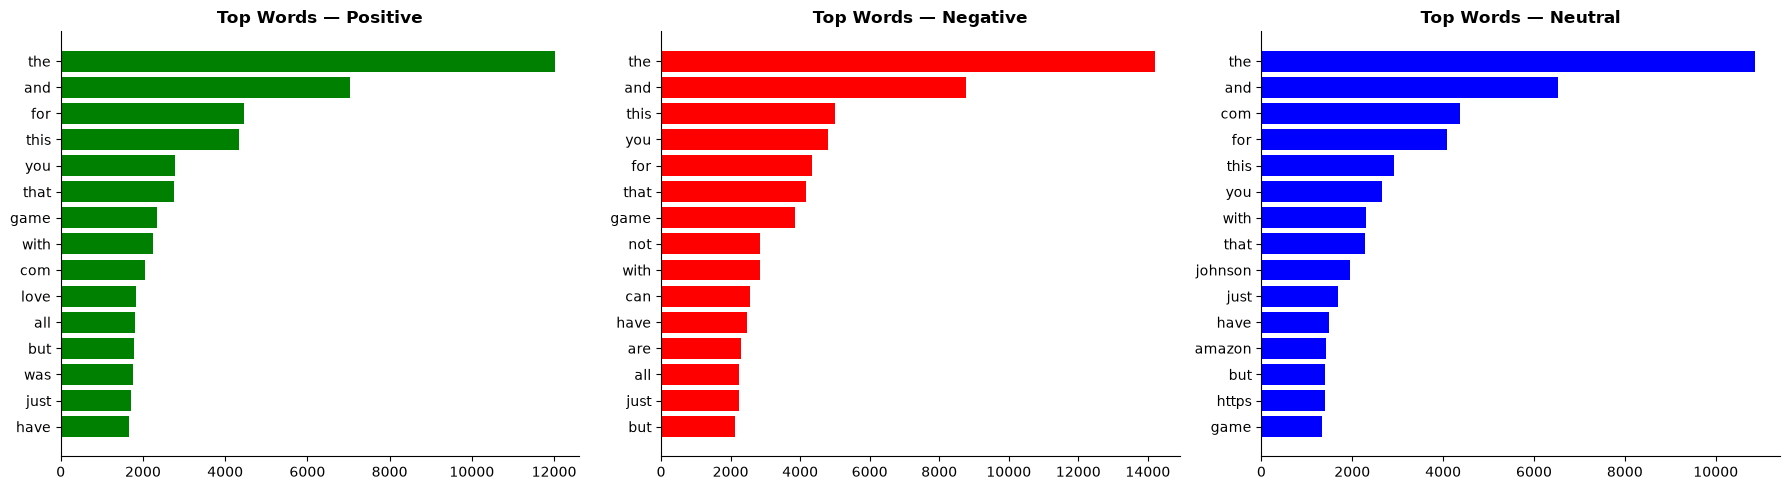

In [26]:
from collections import Counter
import re

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, sentiment, color in zip(axes,
    ['Positive', 'Negative', 'Neutral'],
    ['green',  'red',  'blue']):

    words  = re.findall(r'\b[a-zA-Z]{3,}\b',
             ' '.join(df[df['sentiment']==sentiment]['text'].astype(str)).lower())
    top    = Counter(words).most_common(15)
    w, c   = zip(*top)

    ax.barh(w[::-1], c[::-1], color=color)
    ax.set_title(f'Top Words — {sentiment}', fontweight='bold')
    ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()

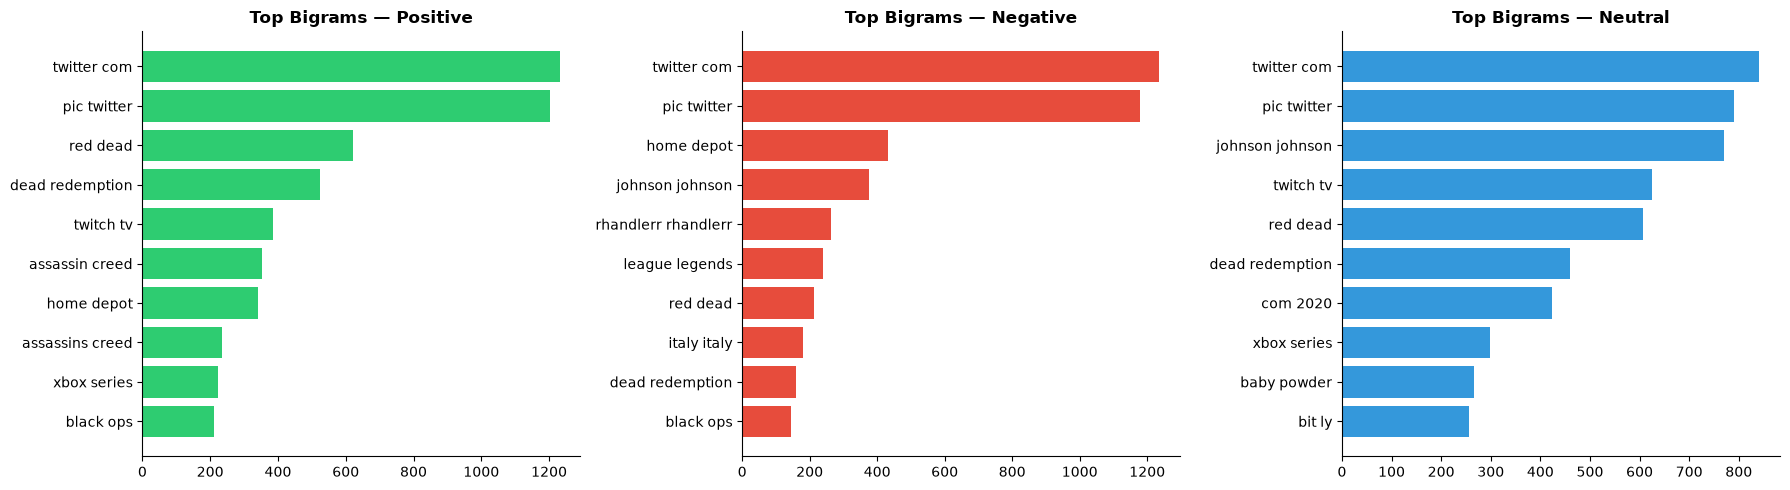

In [27]:
# Biagrams

from sklearn.feature_extraction.text import CountVectorizer

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, sentiment, color in zip(axes,
    ['Positive', 'Negative', 'Neutral'],
    ['#2ecc71',  '#e74c3c',  '#3498db']):

    texts  = df[df['sentiment']==sentiment]['text'].astype(str).tolist()
    vec    = CountVectorizer(ngram_range=(2,2), max_features=10000,
                             stop_words='english').fit(texts)
    sums   = vec.transform(texts).sum(axis=0).A1
    top_i  = sums.argsort()[-10:][::-1]
    vocab  = {v:k for k,v in vec.vocabulary_.items()}
    phrases, counts = zip(*[(vocab[i], sums[i]) for i in top_i])

    ax.barh(phrases[::-1], counts[::-1], color=color)
    ax.set_title(f'Top Bigrams — {sentiment}', fontweight='bold')
    ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()

In [28]:
print(f"Total records : {len(df):,}")
print(f"Sentiments    : {df['sentiment'].unique().tolist()}")
print(f"Avg words     : {df['word_count'].mean():.0f}")

print("\nClass split:")

print(df['sentiment'].value_counts().to_frame('count')
      .assign(pct=lambda x: (x['count']/len(df)*100).round(1).astype(str)+'%'))

df[['text','sentiment']].to_csv('../data/clean_data.csv', index=False)

print("\nSaved clean_data.csv")

Total records : 61,949
Sentiments    : ['Positive', 'Neutral', 'Negative']
Avg words     : 19

Class split:
           count    pct
sentiment              
Negative   22624  36.5%
Positive   20932  33.8%
Neutral    18393  29.7%

Saved clean_data.csv
